In [81]:
import os
import sys
import random
import numpy as np
import cv2
import torch
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

In [82]:
def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [83]:
@dataclass
class CFG: 
    batch_size : int = 16
    lr : float = 5e-5
    seed: int = 42
    lr_weight_decay : float = 0.80
    weight_decay : float = 1e-4
    number_of_channels : int = 3
    criterion : nn.Module = nn.CrossEntropyLoss()
    epochs : int = 30
    device : str = 'mps' if torch.backends.mps.is_available() else 'cpu'
    img_size : int = 96
    base_path : str = 'imagebits'
    number_of_pictures_example: int = 5
    train_path : str = os.path.join(base_path, 'train')
    test_path : str = os.path.join(base_path, 'test')
    image_extension : str = '.png'
    mapping_between_folders_and_classes = {
        'airplane': '1',
        'bird': '2',
        'car': '3',
        'cat': '4',
        'deer': '5',
        'dog': '6',
        'horse': '7',
        'monkey': '8',
        'ship': '9',
        'truck': '10'
    }
    num_classes : int = len(mapping_between_folders_and_classes)
    imagenet_mean  = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

In [84]:
class_distribution = {}

for class_folder in sorted(os.listdir(CFG.train_path)):
    class_path = os.path.join(CFG.train_path, class_folder)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if f.endswith(CFG.image_extension)])
        class_distribution[class_folder] = num_images

In [85]:
def remap_dictionary_keys_to_names_of_objects(original_dictionary):
    reversed_mapping = {v: k for k, v in CFG.mapping_between_folders_and_classes.items()}
    return {reversed_mapping.get(k, k): v for k, v in original_dictionary.items()}

new_dictionary = remap_dictionary_keys_to_names_of_objects(class_distribution)


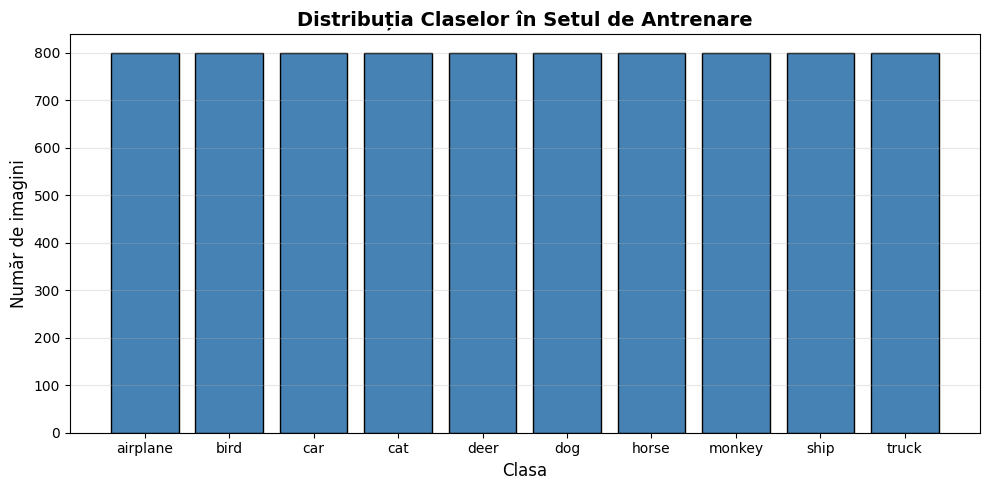

In [86]:
plt.figure(figsize=(10, 5))
classes = sorted(new_dictionary.keys(), key=lambda x: int(CFG.mapping_between_folders_and_classes[x]))
counts = [new_dictionary[c] for c in classes]
plt.bar(classes, counts, color='steelblue', edgecolor='black')
plt.xlabel('Clasa', fontsize=12)
plt.ylabel('Număr de imagini', fontsize=12)
plt.title('Distribuția Claselor în Setul de Antrenare', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
is_balanced = len(set(class_distribution.values())) == 1
print(f"Dataset-ul este {'Echilibrat' if is_balanced else 'Dezechilibrat'}")

Dataset-ul este Echilibrat


In [88]:
def get_parameters_for_type_of_operation(type = 'picture_stats'):
    if type == 'picture_stats':
        return [],{}
    elif type == 'correlation_purpose':
        return [],[]
    elif type == 'plot_images':
        return [],[]
    elif type == 'make_csv_files':
        return [],[]
    
    return None

In [89]:
def get_random_images_to_plot(all_images):
    random.seed(CFG.seed)
    return random.sample(all_images, min(CFG.number_of_pictures_example, len(all_images)))

In [90]:
def set_path(train=True):
    return CFG.train_path if train else CFG.test_path

In [91]:
def get_path(class_idx,train=True):
    return os.path.join(set_path(train), str(class_idx))

In [92]:
def get_all_images(class_idx,train=True):
    return [f for f in os.listdir(get_path(class_idx,train)) if f.endswith(CFG.image_extension)]

In [93]:
def read_images(image_name,class_idx,train=True):
    img_path = os.path.join(get_path(class_idx,train),image_name)
    return img_path, cv2.imread(img_path)

In [94]:
def prepare_plot():
    fig, axes = plt.subplots(CFG.num_classes, CFG.number_of_pictures_example, figsize=(16, 20))
    fig.suptitle('Exemple din Fiecare Clasă - Variabilitate Intra-Clasă', fontsize=16, fontweight='bold')
    return fig, axes

In [95]:
def plot_examples_from_dataset(image,axes,class_idx,img_idx):
    ax = axes[class_idx - 1, img_idx]
    ax.imshow(image)
    ax.axis('off')
        
    if img_idx == 0:
        ax.set_title(f'Clasa {class_idx}', fontsize=12, fontweight='bold', loc='left')

In [96]:
def process_all_images(number_of_classes=CFG.num_classes, operation_type='picture_stats', train=True):
    container1, container2 = get_parameters_for_type_of_operation(operation_type)

    if operation_type == 'plot_images':
        _, axes = prepare_plot()
    
    for class_idx in range(1, number_of_classes + 1):
        all_images = get_all_images(class_idx, train=train)

        if operation_type == 'plot_images':
            all_images = get_random_images_to_plot(all_images)
        
        class_pixels = [] 
        for img_name in all_images:
            img_path, image = read_images(img_name, class_idx, train=train)
            
            if image is None:
                continue
            
            if operation_type == 'picture_stats':
                container1.append(image.shape[:2]) 
                class_pixels.append(np.array(image))
                
            elif operation_type == 'correlation_purpose':
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                vector = image_rgb.flatten()
                container1.append(vector)
                container2.append(class_idx)
                
            elif operation_type == 'plot_images':
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                plot_examples_from_dataset(image_rgb, axes, class_idx, img_idx=all_images.index(img_name))

            elif operation_type == 'make_csv_files':
                container1.append({'ID': img_path, 'label': class_idx})
                
        if operation_type == 'picture_stats' and class_pixels:
            class_pixels_np = np.array(class_pixels)
            container2[class_idx] = {
                'mean': np.mean(class_pixels_np),
                'std': np.std(class_pixels_np),
                'min': np.min(class_pixels_np),
                'max': np.max(class_pixels_np)
            }

    if operation_type == 'correlation_purpose':
        return np.array(container1), np.array(container2)
    
    if operation_type == 'plot_images':
        plt.tight_layout()
        plt.show()
    
    return container1, container2

In [97]:
image_sizes, pixel_stats_per_class = process_all_images()
print(f"\n{'Dimensiuni imagini:':<25} {Counter(image_sizes).most_common(1)[0][0]}")

print("-" * 60)
print("Statistici pixeli per clasă (Media ± Deviație Standard):")
print("-" * 60)

for class_idx in range(1, CFG.num_classes + 1):
    stats = pixel_stats_per_class[class_idx]
    print(f"Clasa {class_idx:2d}: {stats['mean']:6.2f} ± {stats['std']:6.2f}  (min: {stats['min']:3.0f}, max: {stats['max']:3.0f})")

print("=" * 60)


Dimensiuni imagini:       (96, 96)
------------------------------------------------------------
Statistici pixeli per clasă (Media ± Deviație Standard):
------------------------------------------------------------
Clasa  1: 133.78 ±  64.77  (min:   0, max: 255)
Clasa  2: 115.26 ±  63.85  (min:   0, max: 255)
Clasa  3:  91.26 ±  72.51  (min:   0, max: 255)
Clasa  4: 105.84 ±  61.50  (min:   0, max: 255)
Clasa  5: 111.59 ±  57.38  (min:   0, max: 255)
Clasa  6: 111.50 ±  65.10  (min:   0, max: 255)
Clasa  7: 104.34 ±  65.11  (min:   0, max: 255)
Clasa  8: 105.09 ±  61.77  (min:   0, max: 255)
Clasa  9: 118.42 ±  71.50  (min:   0, max: 255)
Clasa 10: 100.98 ±  76.34  (min:   0, max: 255)


In [98]:
X, y = process_all_images(operation_type = 'correlation_purpose')
corr_matrix = np.corrcoef(X)

intra_correlations = []
inter_correlations = []
num_samples = len(y)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

class_mask = (y[:, None] == y[None, :]) & mask

intra_correlations = corr_matrix[class_mask]
inter_correlations = corr_matrix[mask & ~class_mask]

avg_intra = np.mean(intra_correlations)
avg_inter = np.mean(inter_correlations)

print(f"Average Intra-class Correlation (Consistency): {avg_intra:.4f}")
print(f"Average Inter-class Correlation (Confusion):   {avg_inter:.4f}")
print(f"Separability Score (Intra - Inter):            {avg_intra - avg_inter:.4f}")

Average Intra-class Correlation (Consistency): 0.0787
Average Inter-class Correlation (Confusion):   0.0206
Separability Score (Intra - Inter):            0.0581


/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_l

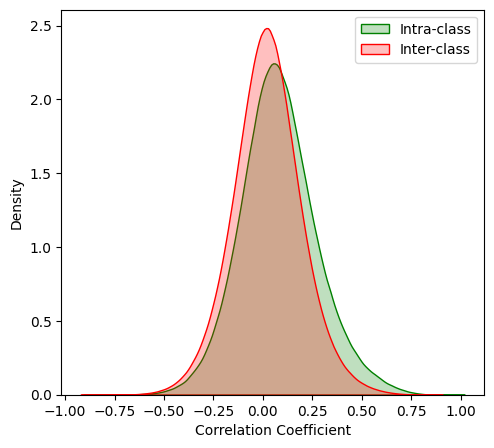

In [99]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(intra_correlations, label='Intra-class', fill=True, color='green')
sns.kdeplot(inter_correlations, label='Inter-class', fill=True, color='red')
plt.xlabel('Correlation Coefficient')
plt.legend()

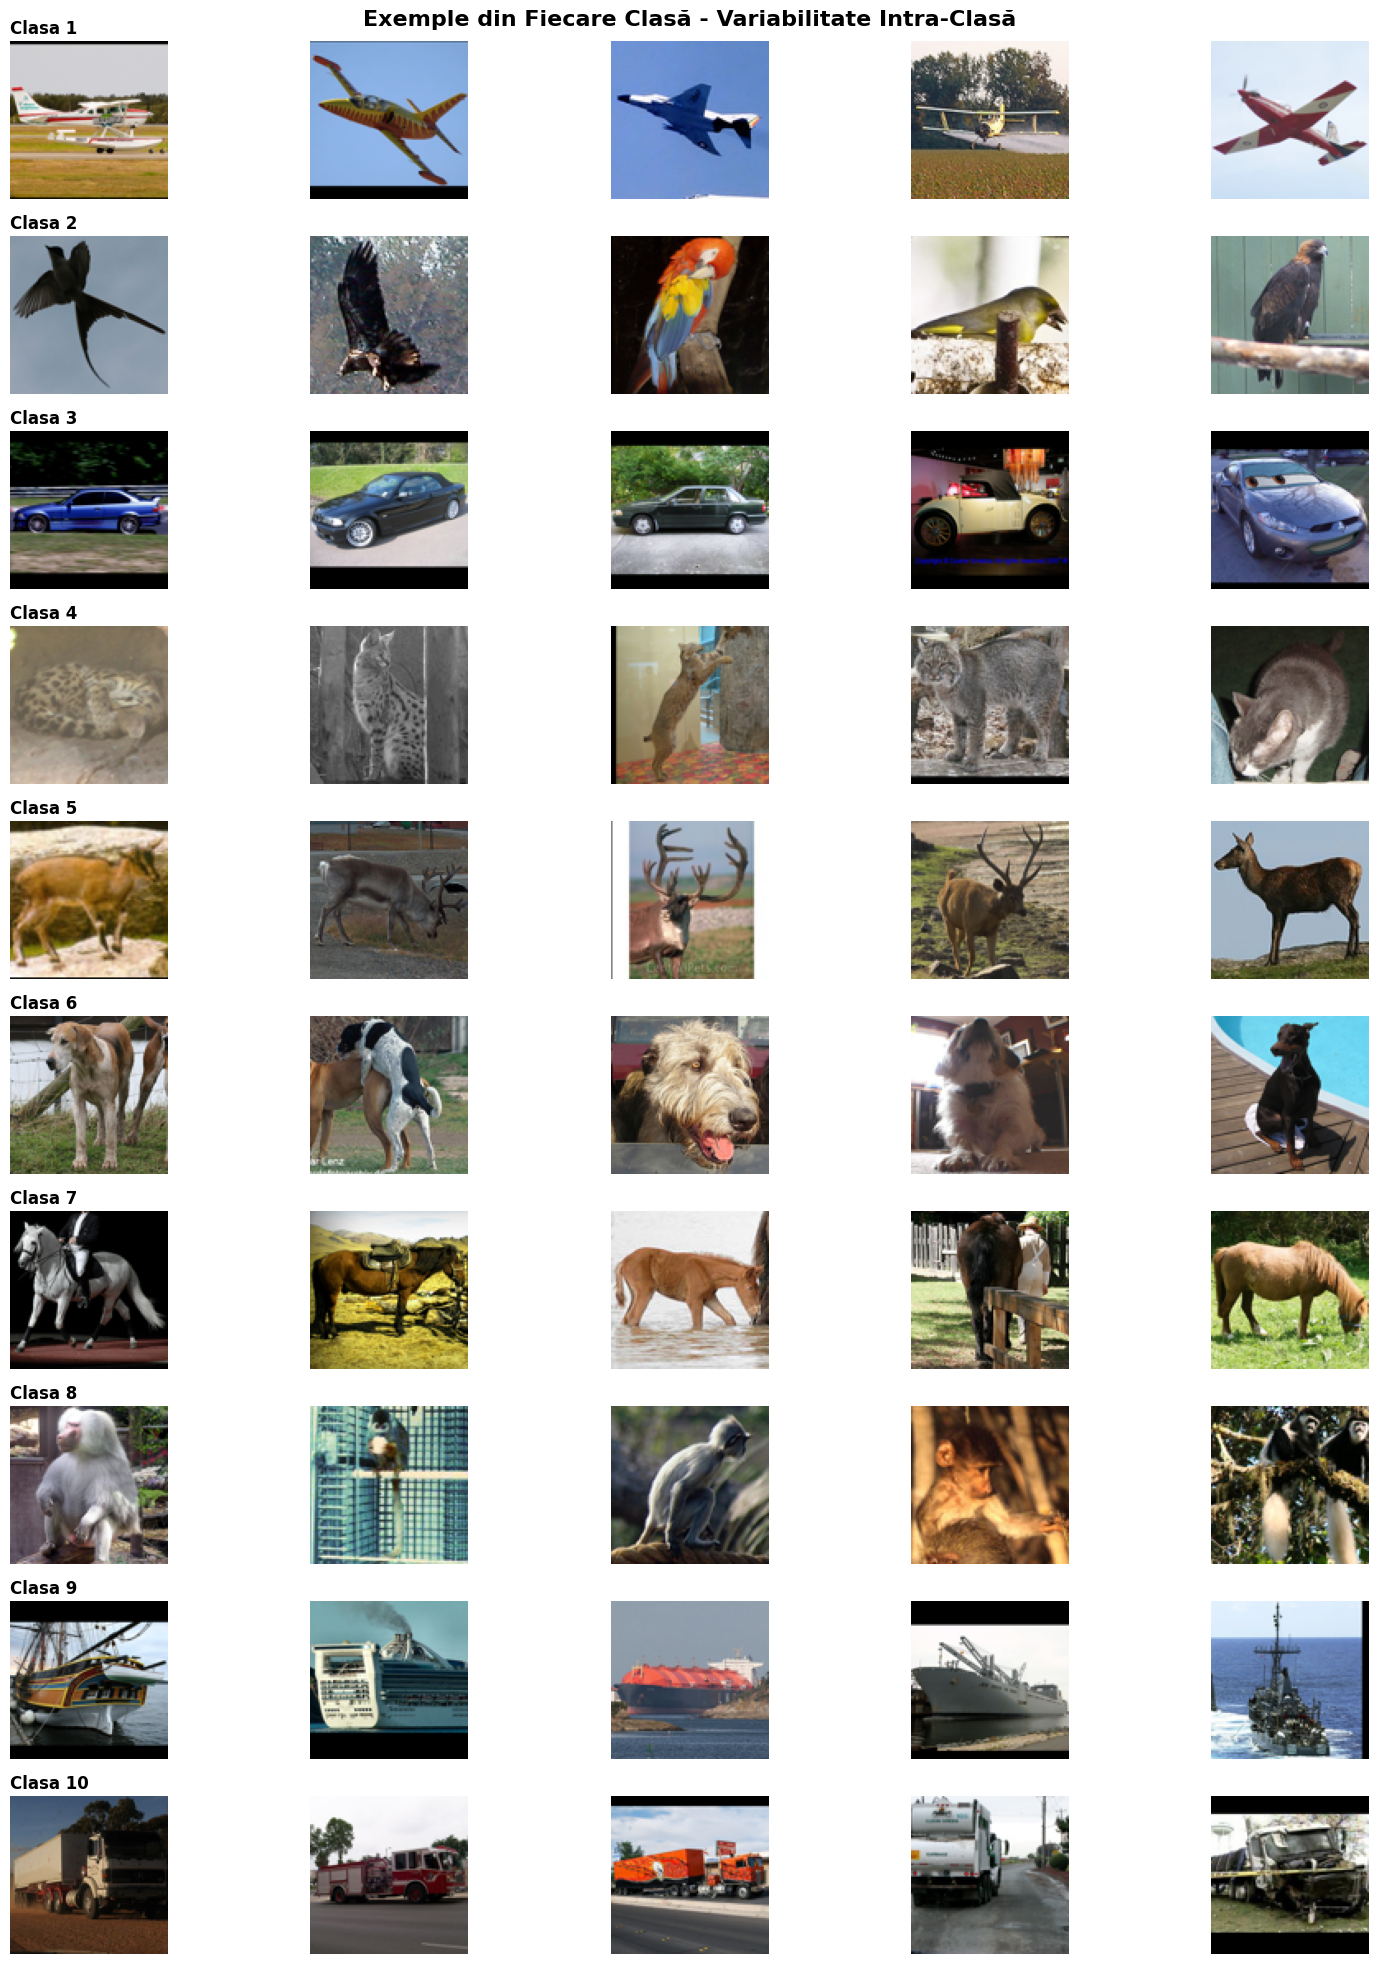

In [100]:
_, _ = process_all_images(operation_type = 'plot_images')

In [101]:
def make_train_and_test_csvs(train=True):
    data, _ = process_all_images(operation_type='make_csv_files', train=train)
    return pd.DataFrame(data)

In [102]:
def locate_csv_to_folders(train=True):
    df = make_train_and_test_csvs(train=train)
    split_name = "train" if train else "test"
    csv_path = os.path.join(set_path(train), f"{split_name}_data.csv")
    df.to_csv(csv_path, index=False)

In [103]:
locate_csv_to_folders(train=True)
locate_csv_to_folders(train=False)

In [104]:
train_set = pd.read_csv(f'{CFG.train_path}/train_data.csv')
test_set = pd.read_csv(f'{CFG.test_path}/test_data.csv')

In [105]:
train_set, val_set = train_test_split(
    train_set, 
    test_size=0.20, 
    stratify=train_set['label'], 
    random_state=CFG.seed
)

In [106]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(in_features=CFG.number_of_channels * CFG.img_size * CFG.img_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=64)
        self.fc4 = nn.Linear(in_features=64, out_features=CFG.num_classes)
 
        self.activation = nn.ReLU()

    def forward(self, x):
        
        x = x.view(-1, CFG.number_of_channels * CFG.img_size * CFG.img_size)

        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))

        x = self.fc4(x)

        return x

In [119]:
class MyDataset(Dataset):
    def __init__(self, df, use_class_specific_aug=False):
        self.df = df
        self.use_class_specific_aug = use_class_specific_aug

        self.resize = transforms.Resize(((CFG.img_size, CFG.img_size)))

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=CFG.imagenet_mean, std=CFG.imagenet_std)
            ])
        
        if self.use_class_specific_aug:
            self.class_transforms = {
                0: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(15),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.8, 1.0)),
                ]),
                2: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(10),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.8, 1.0)),
                ]),
                8: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(15),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.8, 1.0)),
                ]),
                9: transforms.Compose([ 
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(10),
                    transforms.ColorJitter(brightness=0.2, contrast=0.2),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.8, 1.0)),
                ]),
                
                1: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(30),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
                3: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(25),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
                4: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(20),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
                5: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(25),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
                6: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(20),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
                7: transforms.Compose([
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomRotation(30),
                    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                    transforms.RandomResizedCrop(CFG.img_size, scale=(0.7, 1.0)),
                ]),
            }
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx): 
        img_name = self.df.iloc[idx]['ID']
        label = self.df.iloc[idx]['label']
        image = Image.open(f'{img_name}')

        label = label - 1 
        
        if self.use_class_specific_aug:
            image = self.resize(image)
            image = self.class_transforms[label](image)
            image = self.normalize(image)
        else:
            image = self.resize(image)
            image = self.normalize(image)
        
        return image, label

train_dataset = MyDataset(train_set, use_class_specific_aug=True)
validation_dataset = MyDataset(val_set, use_class_specific_aug=False)
test_dataset = MyDataset(test_set, use_class_specific_aug=False)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=CFG.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

In [108]:
def get_number_of_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [109]:
def top_k_accuracy(k, target, output, device):
    batch_size = target.size(0)
    
    _, pred = output.topk(k, 1, True, True)
    
    pred = pred.t()
    
    correct = pred.eq(target.to(device).view(1, -1).expand_as(pred))
    
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
    correct_k = correct_k.mul_(100.0 / batch_size)
    
    return correct_k.item()

In [110]:
def train(model, optimizer, criterion, train_loader, device, epoch):
    model.train()
    running_loss = 0.0
    running_top1_acc = 0.0
    
    bar = tqdm(enumerate(train_loader), total=len(train_loader), colour='cyan', file=sys.stdout)
    
    for i, (images, labels) in bar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        
        top1_acc = top_k_accuracy(1, labels, outputs, device)
        
        running_loss += loss.item() * images.size(0)
        running_top1_acc += top1_acc * images.size(0)
        
        avg_loss = running_loss / ((i + 1) * images.size(0))
        avg_top1 = running_top1_acc / ((i + 1) * images.size(0))
        
        bar.set_postfix({
            'epoch': epoch,
            'train_loss': f'{avg_loss:.4f}',
            'top1_accuracy': f'{avg_top1:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_top1 = running_top1_acc / len(train_loader.dataset)
    
    return epoch_loss, epoch_top1

In [111]:
def validate(model, criterion, val_loader, device, epoch):
    model.eval()
    running_loss = 0.0
    running_top1_acc = 0.0
    
    bar = tqdm(enumerate(val_loader), total=len(val_loader), colour='green', file=sys.stdout)
    
    with torch.no_grad():
        for i, (images, labels) in bar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels.long())
            
            top1_acc = top_k_accuracy(1, labels, outputs, device)
            
            running_loss += loss.item() * images.size(0)
            running_top1_acc += top1_acc * images.size(0)
            
            avg_loss = running_loss / ((i + 1) * images.size(0))
            avg_top1 = running_top1_acc / ((i + 1) * images.size(0))
            
            bar.set_postfix({
                'epoch': epoch,
                'val_loss': f'{avg_loss:.4f}',
                'top1_accuracy': f'{avg_top1:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_top1 = running_top1_acc / len(val_loader.dataset)
    
    return epoch_loss, epoch_top1

In [112]:
def get_predictions_and_labels(model, data_loader, device):    
    model.eval()            
    all_preds = []    
    all_labels = []            

    with torch.no_grad():            
        for images, labels in data_loader:            
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [113]:
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)
    
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=5)
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=5)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Curbe de Loss pentru Antrenare și Validare', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [114]:
def plot_accuracy_curves(train_top1, val_top1):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_top1) + 1)
    
    plt.plot(epochs, train_top1, 'b-o', label='Training Top-1 Accuracy', linewidth=2, markersize=5)
    plt.plot(epochs, val_top1, 'r-o', label='Validation Top-1 Accuracy', linewidth=2, markersize=5)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Acuratețe (%)', fontsize=14)
    plt.title('Curbe de Acuratețe pentru Antrenare și Validare', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [115]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(1, CFG.num_classes + 1),
                yticklabels=range(1, CFG.num_classes + 1),
                cbar_kws={'label': 'Număr de predicții'})
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title('Matricea de Confuzie', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return cm

In [116]:
def calculate_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted') * 100

In [117]:
def create_performance_table(configs_results):
    df = pd.DataFrame(configs_results)
    
    print("\n" + "="*80)
    print("TABEL DE PERFORMANȚĂ - CONFIGURAȚII ARHITECTURALE ȘI DE OPTIMIZARE")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80 + "\n")
    
    return df

In [120]:
model = Net()
model.to(CFG.device)
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

print(f"Model has {get_number_of_parameters(model):,} trainable parameters")

train_losses, train_top1 = [], []
val_losses, val_top1 = [], []

best_val_acc = 0.0
best_epoch = 0

for epoch in range(1, CFG.epochs + 1):
    print(f"\n{'='*60}\nEpoch {epoch}/{CFG.epochs}\n{'='*60}")
    
    tr_loss, tr_acc1 = train(model, optimizer, CFG.criterion, train_loader, CFG.device, epoch)
    train_losses.append(tr_loss)
    train_top1.append(tr_acc1)
    
    print(f"Train - Loss: {tr_loss:.4f}, Top-1: {tr_acc1:.2f}%")
    
    val_loss, val_acc1 = validate(model, CFG.criterion, validation_loader, CFG.device, epoch)
    val_losses.append(val_loss)
    val_top1.append(val_acc1)
    
    print(f"Val   - Loss: {val_loss:.4f}, Top-1: {val_acc1:.2f}%")
    
    if val_acc1 > best_val_acc:
        best_val_acc = val_acc1
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ Best model saved (Top-1: {best_val_acc:.2f}%)")

    if epoch % 3 == 0:
        plot_loss_curves(train_losses, val_losses)
        plot_accuracy_curves(train_top1, val_top1)

print(f"\n{'='*60}\nTraining Complete!\n{'='*60}")
print(f"Best Validation Top-1 Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

plot_loss_curves(train_losses, val_losses)
plot_accuracy_curves(train_top1, val_top1)

Model has 7,119,946 trainable parameters

Epoch 1/30
100%|██████████| 400/400 [00:13<00:00, 30.52it/s, epoch=1, train_loss=1.9233, top1_accuracy=29.41%]
Train - Loss: 1.9233, Top-1: 29.41%
100%|██████████| 100/100 [00:01<00:00, 77.38it/s, epoch=1, val_loss=1.8227, top1_accuracy=34.81%]
Val   - Loss: 1.8227, Top-1: 34.81%
✓ Best model saved (Top-1: 34.81%)

Epoch 2/30
 27%|██▋       | 107/400 [00:03<00:09, 30.46it/s, epoch=2, train_loss=1.7472, top1_accuracy=34.70%]


KeyboardInterrupt: 

In [ ]:
print(f"\n{'='*60}\nTest Set Evaluation\n{'='*60}")
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc1 = validate(model, CFG.criterion, test_loader, CFG.device, 'Final')

y_pred, y_true = get_predictions_and_labels(model, test_loader, CFG.device)
test_f1 = calculate_f1_score(y_true, y_pred)

print(f"\nFinal Test Results:")
print(f"  Test Loss:         {test_loss:.4f}")
print(f"  Test Top-1 Acc:    {test_acc1:.2f}%")
print(f"  Test F1 Score:     {test_f1:.2f}%")

In [ ]:
print("\nGenerating confusion matrix...")
cm = plot_confusion_matrix(y_true, y_pred)

config_results = [{
    'Configurație': 'MLP (512-256-128)',
    'Learning Rate': CFG.lr,
    'Batch Size': CFG.batch_size,
    'Epochs': CFG.epochs,
    'Optimizer': 'Adam',
    'Acuratețe (%)': f'{test_acc1:.2f}',
    'F1 Score (%)': f'{test_f1:.2f}',
    'Loss': f'{test_loss:.4f}'
}]

performance_df = create_performance_table(config_results)